In [107]:
"""Generate plots for neighborhood enrichment analysis results."""

import gc
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch


In [108]:
# Define functions
def load_nhood_enrichment_zscores(input_dir: Path):
    """Load neighborhood enrichment z-scores for each ROI.

    Parameters:
        input_dir : Path
            Directory containing ROI subdirectories with zscore files

    Returns:
        dict
            {roi_name: dataframe}

    """
    results = {}

    # iterate over ROI subdirectories
    for roi_dir in input_dir.iterdir():
        if not roi_dir.is_dir():
            continue

        roi_name = roi_dir.name

        # wildcard search for zscore file
        zscore_files = list(roi_dir.glob("*_nhood_enrichment_zscores.csv"))

        if not zscore_files:
            continue

        if len(zscore_files) > 1:
            raise ValueError(
                f"Multiple zscore files found for {roi_name}: {zscore_files}"
            )

        zscore_file = zscore_files[0]

        # read file
        df = pd.read_csv(zscore_file, index_col=0)

        results[roi_name] = df

    return results


def make_clustermap(
    cell_type, celltype_dict, meta, meta_cols, cmap="vlag", fig_path=None, palette=None
):
    safe_cell_type = cell_type.replace("/", "_").replace(" ", "_")

    celltype_df = pd.DataFrame(celltype_dict[cell_type])
    heatmap_df = celltype_df.apply(pd.to_numeric, errors="coerce").fillna(0)

    for col in meta_cols:
        if col not in meta.columns:
            raise ValueError(f"Missing metadata column: {col}")

    meta_subset = meta.loc[heatmap_df.columns, meta_cols]

    # Build col_colors DataFrame regardless of whether palette is provided
    col_colors = pd.DataFrame(index=heatmap_df.columns)
    palettes = {}

    for col in meta_cols:
        unique_vals = meta_subset[col].unique()

        if palette is None:
            col_colors = pd.DataFrame(index=heatmap_df.columns)
            palettes = {}

            for col in meta_cols:
                unique_vals = meta_subset[col].unique()
                length = len(unique_vals)
                col_palette = dict(zip(unique_vals, sns.color_palette("husl", length)))
                palettes[col] = col_palette
                col_colors[col] = meta_subset[col].map(col_palette)

        else:
            palettes = {col: palette for col in meta_cols}
            col_colors = pd.DataFrame(
                {col: meta_subset[col].map(palette) for col in meta_cols},
                index=heatmap_df.columns,
            )

    # Set order the columns for the clustermap based on diagnosis
    if "diagnosis" in meta_cols:
        diagnosis_order = ["NO_CRD", "LUNG_CANCER", "IPF"]
        col_colors = col_colors.loc[
            meta_subset["diagnosis"]
            .map(lambda x: diagnosis_order.index(x) if x in diagnosis_order else -1)
            .sort_values()
            .index
        ]
        heatmap_df = heatmap_df[col_colors.index]

    g = sns.clustermap(
        heatmap_df,
        cmap=cmap,
        center=0,
        linewidths=0.5,
        figsize=(10, 8),
        col_colors=col_colors,  # always a DataFrame now
        xticklabels=True,
        yticklabels=True,
        # col_cluster=False,
    )

    g.figure.suptitle(f"{cell_type} - Neighborhood Enrichment Z-scores", y=1.02)

    legend_handles = []
    for col in meta_cols:
        for level, color in palettes[col].items():
            legend_handles.append(Patch(facecolor=color, label=f"{col}: {level}"))

    g.ax_heatmap.legend(
        handles=legend_handles,
        title="Metadata",
        bbox_to_anchor=(1.6, 1),
        loc="upper left",
        frameon=False,
    )

    plt.savefig(
        fig_path / f"{safe_cell_type}_nhood_enrichment_clustermap.pdf",
        bbox_inches="tight",
    )
    plt.close()


In [109]:
# Base project path
base_path = Path(
    "/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/"
)

# Analysis paths
analysis_path = base_path / "output" / "2026-03-27_analysis_run"
spatial_stats_path = analysis_path / "spatial_stats"

# Input
input_dir = spatial_stats_path / "ROI_spatial_statistics" / "30_radius"

# Output directories
outpath = (
    spatial_stats_path / "ROI_spatial_statistics" / "30_radius_manual" / "nhood_manual"
)
heatmap_path = outpath / "IPFvPM08" / "heatmaps_zscores"
barplot_path_zscore = outpath / "IPFvPM08" / "barplots_zscores"

# Create directories
for path in [outpath, heatmap_path, barplot_path_zscore]:
    path.mkdir(parents=True, exist_ok=True)

# Plot heatmap of z-scores for each condition
cmap = sns.color_palette("vlag", as_cmap=True)
diagnosis_palette = {
    "IPF": "#6A7FB5",  # slate blue
    "LUNG_CANCER": "#B07D4A",  # warm tan
    "COPD": "#7EB0B8",  # dusty teal
    "HEALTHY": "#8EA882",  # sage
    "NO_CRD": "#A67B8A",  # muted rose
}

# Load metadata
meta = pd.read_csv(
    base_path / "data/meta/STx_meta_analysis_only_cleaned.csv", index_col=0
)

In [110]:
# Import zscores for neighborhood enrichment analysis results
ROI_zscore_dict = load_nhood_enrichment_zscores(input_dir)

In [111]:
# Get list of all cell types across conditions
cell_type_list = next(iter(ROI_zscore_dict.values())).index.tolist()

# Make empty dict to store combined dataframes for each cell type
celltype_dict = {}

# Combine dataframes for each cell type across conditions
for cell_type in cell_type_list:
    combined = pd.DataFrame(
        {
            condition: df.loc[cell_type]
            if cell_type in df.index
            else pd.Series(float("nan"), index=df.columns)
            for condition, df in ROI_zscore_dict.items()
        }
    )

    celltype_dict[cell_type] = combined

In [112]:
# Remove COPD and MICA samples to focus on IPF vs PM08 comparison from celltype_dict
for cell_type in cell_type_list:
    celltype_dict[cell_type] = celltype_dict[cell_type].drop(
        columns=[col for col in celltype_dict[cell_type].columns if "COPD" in col]
        + [col for col in celltype_dict[cell_type].columns if "MICA" in col]
    )

In [113]:
# Data
meta_column = "diagnosis"
celltype_of_interest = "Interstitial Macrophages"

safe_cell_type = celltype_of_interest.replace("/", "_").replace(" ", "_")

# Desired diagnosis order
diagnosis_order = ["NO_CRD", "LUNG_CANCER", "IPF"]


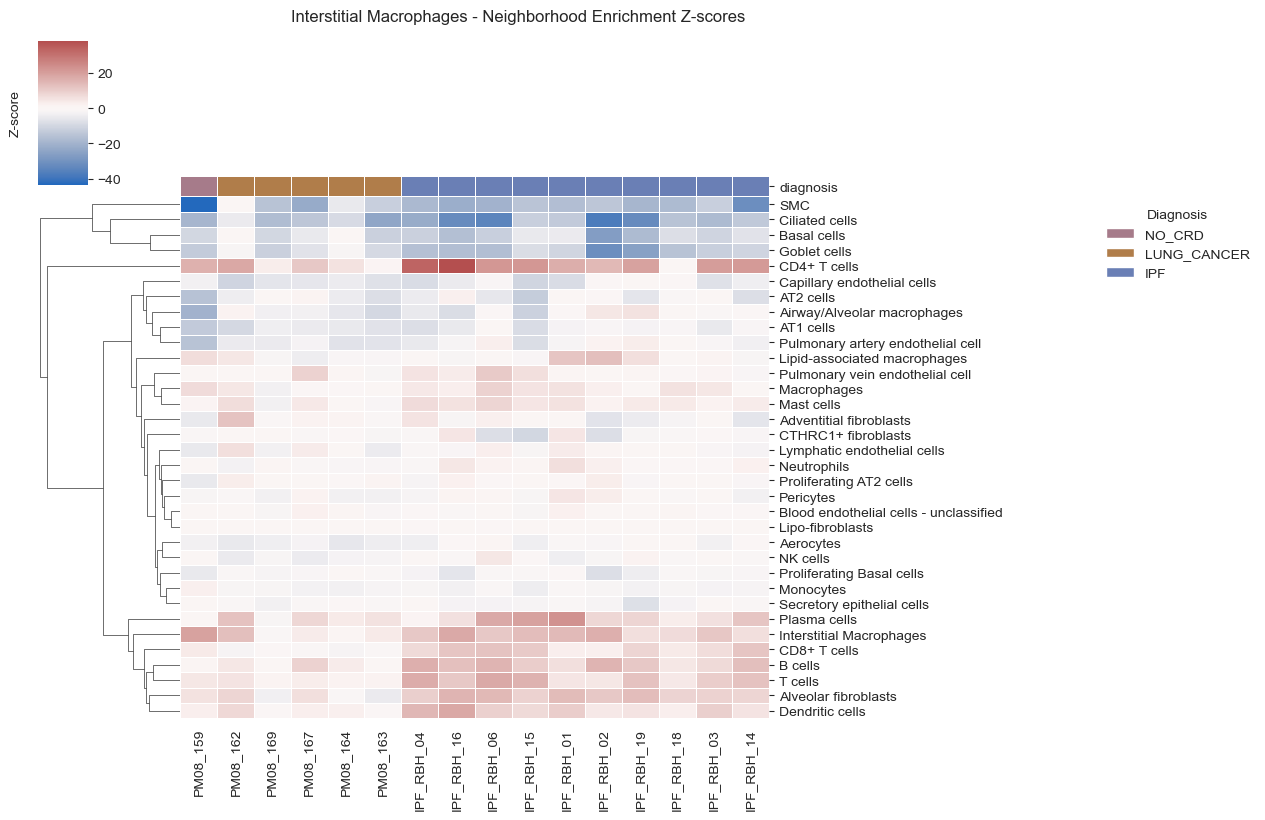

In [114]:
# HEATMAP OF ZSCORE
# Heatmap data
celltype_df = pd.DataFrame(celltype_dict[celltype_of_interest])
heatmap_df = celltype_df.apply(pd.to_numeric, errors="coerce").fillna(0)

# Metadata aligned to heatmap columns
meta_subset = meta.loc[heatmap_df.columns, meta_column]

# Order samples by diagnosis
ordered_columns = (
    meta_subset.map(
        lambda x: diagnosis_order.index(x)
        if x in diagnosis_order
        else len(diagnosis_order)
    )
    .sort_values()
    .index
)

heatmap_df = heatmap_df[ordered_columns]
meta_subset = meta_subset.loc[ordered_columns]

# Column annotation colors
col_colors = meta_subset.map(diagnosis_palette)

# Plot
g = sns.clustermap(
    heatmap_df,
    cmap=cmap,
    center=0,
    linewidths=0.5,
    figsize=(10, 8),
    col_colors=col_colors,
    xticklabels=True,
    yticklabels=True,
    col_cluster=False,
)

g.figure.suptitle(
    f"{celltype_of_interest} - Neighborhood Enrichment Z-scores",
    y=1.02,
)

g.ax_cbar.set_ylabel("Z-score", rotation=90, labelpad=-80)

# Legend
legend_handles = [
    Patch(facecolor=diagnosis_palette[diag], label=diag)
    for diag in diagnosis_order
    if diag in diagnosis_palette
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Diagnosis",
    bbox_to_anchor=(1.55, 1),
    loc="upper left",
    frameon=False,
)

plt.show()

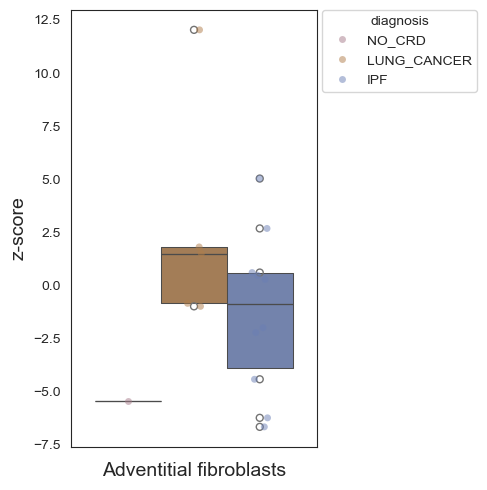

In [119]:
cell_type_2_of_interest = "Adventitial fibroblasts"

if meta_column not in meta.columns:
    raise ValueError(f"Metadata column '{meta_column}' not found in meta dataframe")

safe_cell_type = celltype_of_interest.replace("/", "_").replace(" ", "_")

# make directory for this cell type if it doesn't exist
celltype_dir = barplot_path_zscore / safe_cell_type
celltype_dir.mkdir(parents=True, exist_ok=True)

# Extract the dataframe for this cell type across conditions
celltype_df = pd.DataFrame(celltype_dict[celltype_of_interest])

# SUBSET ON CELL TYPE 2 OF INTEREST
celltype_df = celltype_df.loc[[cell_type_2_of_interest]]


# Transpose and melt the dataframe for plotting
plot_df = celltype_df.transpose().reset_index().rename(columns={"index": "ROI"})

plot_df = plot_df.melt(
    id_vars="ROI", var_name="Neighbor Cell Type", value_name="Z-score"
)

# # Add condition column by extracting from ROI name
plot_df = plot_df.merge(meta, left_on="ROI", right_index=True)

# Drop NaN values before plotting
plot_df = plot_df.dropna(subset=["Z-score"])

# Set order of conditions for plotting if diagnosis column is present
if "diagnosis" in plot_df.columns:
    diagnosis_order = ["NO_CRD", "LUNG_CANCER", "IPF"]
    plot_df["diagnosis"] = pd.Categorical(
        plot_df["diagnosis"],
        categories=diagnosis_order,
        ordered=True,
    )

sns.set_style("white")
fig, ax = plt.subplots(figsize=(5, 5))

sns.stripplot(
    data=plot_df,
    x="Neighbor Cell Type",
    y="Z-score",
    hue=meta_column,
    dodge=True,
    alpha=0.5,
    palette=diagnosis_palette,
    ax=ax,
)

sns.boxenplot(
    data=plot_df,
    x="Neighbor Cell Type",
    y="Z-score",
    hue=meta_column,
    dodge=True,
    palette=diagnosis_palette,
    ax=ax,
)

# Remove duplicate legends
handles, labels = ax.get_legend_handles_labels()
n = len(plot_df[meta_column].unique())

ax.legend(
    handles[:n],
    labels[:n],
    title=meta_column,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
)

#ax.set_title(f"{celltype_of_interest} - Neighborhood Enrichment Z-scores")
ax.set_xticklabels([""])
ax.set_xlabel(cell_type_2_of_interest, fontsize=14)
ax.set_ylabel("z-score", fontsize=14)

plt.tight_layout()
plt.savefig(
    celltype_dir / f"{safe_cell_type}_and_{cell_type_2_of_interest}_{meta_column}_nhood_enrichment_zscores.pdf"
)

